In [1]:
import pandas as pd
import numpy as np

prices = pd.read_csv(
    "../data/prices.csv",
    index_col=0,
    parse_dates=True
)

prices.head()

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.267078,136.742554,59.450500,88.292404,282.886383,131.293930,102.634377,30.269539,88.640495,106.224525,...,78.699928,56.421844,4.922529,72.280716,127.825645,110.094933,191.993881,107.888252,33.712955,28.800240
2018-01-03,40.260059,139.322906,60.209999,88.836777,283.801239,131.494537,103.499397,30.511000,89.286644,106.680595,...,79.066162,56.412956,5.246499,72.192986,128.338547,110.445290,194.007904,108.962334,33.020176,29.051458
2018-01-04,40.447075,138.735779,60.479500,90.314392,282.724426,133.300400,104.865761,30.597322,89.008736,106.633095,...,79.762054,56.377411,5.274156,72.703316,127.640266,110.445290,194.850021,109.367455,33.127251,29.077751
2018-01-05,40.907562,139.562393,61.457001,90.520370,294.322327,135.407333,106.261620,31.021097,88.862816,106.053505,...,80.750977,56.857292,5.318850,72.751152,130.285141,110.245094,198.565643,111.986710,33.051670,29.250097
2018-01-08,40.755630,139.523788,62.343498,89.687523,295.570770,138.810043,107.008705,31.342834,89.300545,104.533295,...,80.833328,57.363838,5.481823,73.133873,131.008133,109.652832,195.119171,112.438950,32.994991,29.682444


In [2]:
returns = prices.pct_change()

returns.head()

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,-0.000174,0.018870,0.012775,0.006166,0.003234,0.001528,0.008428,0.007977,0.007290,0.004293,...,0.004654,-0.000158,0.065814,-0.001214,0.004013,0.003182,0.010490,0.009955,-0.020549,0.008723
2018-01-04,0.004645,-0.004214,0.004476,0.016633,-0.003794,0.013733,0.013202,0.002829,-0.003113,-0.000445,...,0.008801,-0.000630,0.005271,0.007069,-0.005441,0.000000,0.004341,0.003718,0.003243,0.000905
2018-01-05,0.011385,0.005958,0.016163,0.002281,0.041022,0.015806,0.013311,0.013850,-0.001639,-0.005435,...,0.012398,0.008512,0.008474,0.000658,0.020721,-0.001813,0.019069,0.023949,-0.002282,0.005927
2018-01-08,-0.003714,-0.000277,0.014425,-0.009201,0.004242,0.025129,0.007031,0.010372,0.004926,-0.014334,...,0.001020,0.008909,0.030641,0.005261,0.005549,-0.005372,-0.017357,0.004038,-0.001715,0.014781


In [5]:
month_ends = prices.resample("ME").last().index
portfolio_returns = []
portfolio_dates = []
month_ends[:5]

DatetimeIndex(['2018-01-31', '2018-02-28', '2018-03-31', '2018-04-30',
               '2018-05-31'],
              dtype='datetime64[us]', name='Date', freq='ME')

In [83]:
portfolio_returns = []
portfolio_dates = []
holdings_records = []   

for i in range(12, len(month_ends)-1):
    formation_date = month_ends[i]
    next_date = month_ends[i+1]

    # use prices up to the formation date to compute momentum
    current_prices = prices.loc[:formation_date]
    momentum = current_prices.pct_change(252)
    latest_momentum = momentum.iloc[-1]

    # select top 5 by momentum
    top5 = (
        latest_momentum
        .sort_values(ascending=False)
        .head(5)
        .index
    )

    #: Store what stocks were selected this month
    holdings_records.append({
        "formation_date": formation_date,
        "holding_until": next_date,
        "holdings": list(top5)
    })

    # equal weights
    weights = np.repeat(1/5, 5)

    # returns for selected stocks during holding month
    holding_period = returns.loc[formation_date:next_date, top5]
    daily_portfolio_return = (holding_period * weights).sum(axis=1)

    # compound daily returns into one monthly return
    monthly_portfolio_return = (1 + daily_portfolio_return).prod() - 1

    # store results
    portfolio_returns.append(monthly_portfolio_return)
    portfolio_dates.append(next_date)

# build time series for strategy returns
portfolio = pd.Series(portfolio_returns, index=portfolio_dates)

# build holdings history table
holdings_history = pd.DataFrame(holdings_records)

portfolio.head()



2019-02-28    0.076045
2019-03-31    0.017181
2019-04-30    0.035743
2019-05-31   -0.033143
2019-06-30    0.054990
dtype: float64

In [28]:
# Display the portfolio performance summary
portfolio.describe()

count    71.000000
mean      0.019289
std       0.059180
min      -0.124776
25%      -0.020743
50%       0.018626
75%       0.055781
max       0.179434
dtype: float64

<Axes: title={'center': 'Momentum Strategy Returns'}>

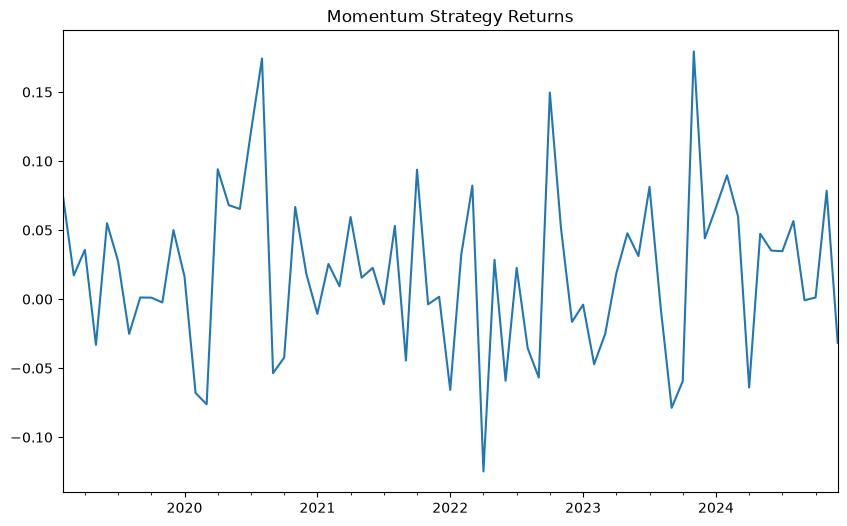

In [84]:
# Plot the cumulative returns of the momentum strategy
portfolio.plot(title="Momentum Strategy Returns", figsize=(10, 6))

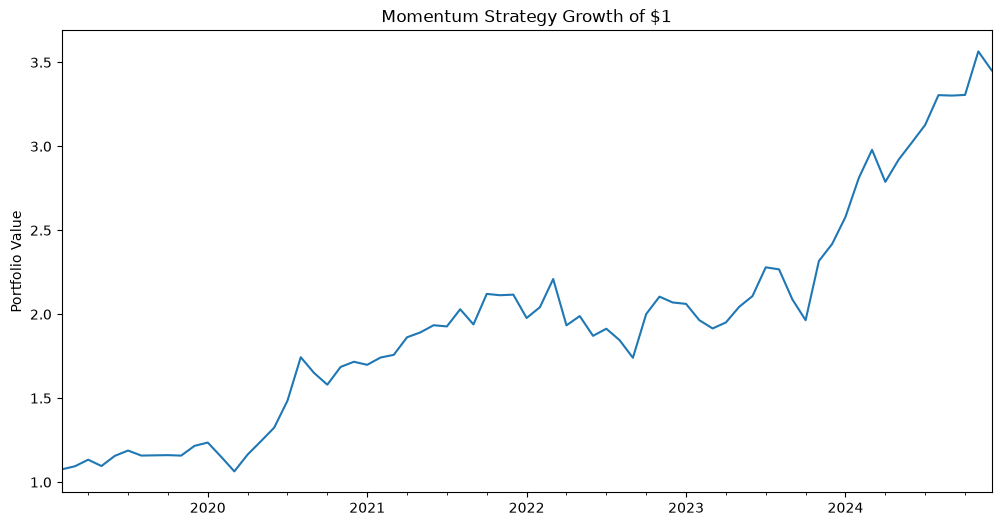

In [85]:
# Calculate the cumulative growth of the portfolio, starting at $1
portfolio_growth = (
    1 + portfolio
).cumprod()

import matplotlib.pyplot as plt
# Plot the cumulative growth of the portfolio
portfolio_growth.plot(
    figsize=(12,6)
)

plt.title(
    "Momentum Strategy Growth of $1"
)

plt.ylabel(
    "Portfolio Value"
)

plt.show()

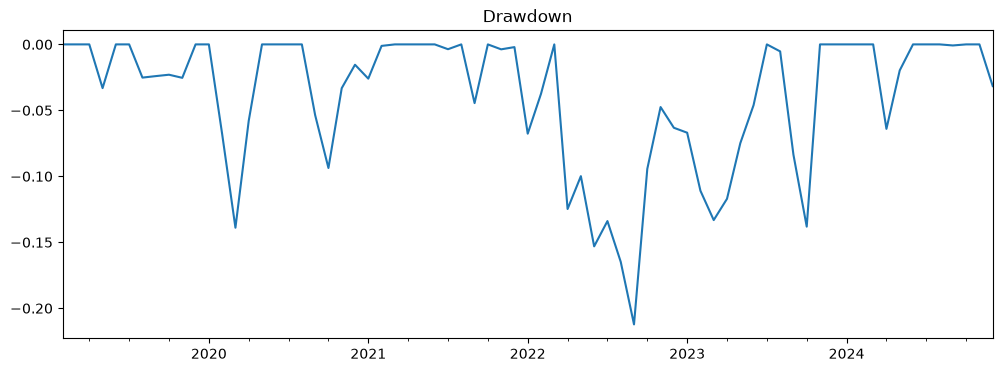

In [86]:
# Calculate the drawdown of the portfolio
running_max = portfolio_growth.cummax()

drawdown = (
    portfolio_growth
    - running_max
) / running_max

# Plot the drawdown of the portfolio
drawdown.plot(
    figsize=(12,4),
    title="Drawdown"
)

plt.show()

In [87]:
# Calculate the annualized return of the portfolio
annual_return = portfolio.mean() * 12

annual_return


np.float64(0.23146794612637123)

In [88]:
# Calculate the annualized volatility of the portfolio
annual_vol = portfolio.std() * np.sqrt(12)

annual_vol

np.float64(0.2050052261588503)

In [89]:
# Calculate the Sharpe ratio of the portfolio
sharpe = annual_return / annual_vol

sharpe

np.float64(1.1290831480901664)

In [90]:
# Calculate the maximum drawdown of the portfolio
max_drawdown = drawdown.min()

max_drawdown

np.float64(-0.2122365734630091)

In [91]:
# Calculate the CAGR of the portfolio
years = (
    portfolio.index[-1]
    -
    portfolio.index[0]
).days / 365.25

cagr = (
    portfolio_growth.iloc[-1]
) ** (1/years) - 1

cagr

np.float64(0.23637401902739263)

In [92]:
# Display the performance metrics in a Performance Summary Table
metrics = pd.DataFrame({
    "Metric": [
        "CAGR",
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Max Drawdown"
    ],
    "Value": [
        cagr,
        annual_return,
        annual_vol,
        sharpe,
        max_drawdown
    ]
})

metrics

,Metric,Value
0,CAGR,0.236374
1,Annual Return,0.231468
2,Annual Volatility,0.205005
3,Sharpe Ratio,1.129083
4,Max Drawdown,-0.212237


In [93]:
import yfinance as yf

# Download SPY data for comparison
spy = yf.download(
    "SPY",
    start="2018-01-01",
    end="2025-01-01",
    auto_adjust=True
)
# Convert to monthly data
spy_close = spy["Close"]["SPY"]
spy_monthly = spy_close.resample("ME").last()
# Calculate SPY  monthly returns
spy_returns = spy_monthly.pct_change()

spy_returns.head()

[*********************100%***********************]  1 of 1 completed



Date
2018-01-31         NaN
2018-02-28   -0.036361
2018-03-31   -0.027410
2018-04-30    0.005168
2018-05-31    0.024309
Freq: ME, Name: SPY, dtype: float64

In [94]:
# Align the SPY dates with the portfolio dates
spy_returns = spy_returns.loc[
    portfolio.index
]
# Calculate the cumulative growth of SPY, starting at $1
spy_growth = (
    1 + spy_returns
).cumprod()

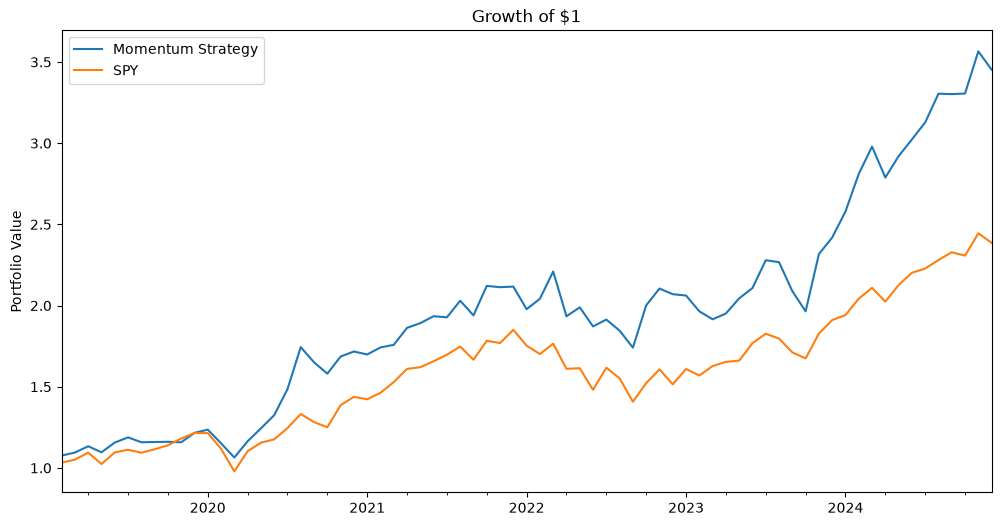

In [95]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12,6))

portfolio_growth.plot(
    ax=ax,
    label="Momentum Strategy"
)

spy_growth.plot(
    ax=ax,
    label="SPY"
)

ax.set_title("Growth of $1")
ax.set_ylabel("Portfolio Value")
ax.legend()

plt.show()

In [96]:
#Function to calculate performance metrics for any given returns and growth series
def calculate_performance_metrics(returns, growth):
    annual_return = returns.mean() * 12
    annual_vol = returns.std() * np.sqrt(12)
    sharpe = annual_return / annual_vol

    years = (returns.index[-1] - returns.index[0]).days / 365.25
    cagr = growth.iloc[-1] ** (1 / years) - 1

    running_max = growth.cummax()
    drawdown = (growth - running_max) / running_max
    max_drawdown = drawdown.min()

    return pd.Series({
        "CAGR": cagr,
        "Annual Return": annual_return,
        "Annual Volatility": annual_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    })

In [97]:

# Calculate performance metrics for SPY
spy_metrics = calculate_performance_metrics(
    spy_returns,
    spy_growth
)

spy_metrics

CAGR                 0.160590
Annual Return        0.162722
Annual Volatility    0.173038
Sharpe Ratio         0.940384
Max Drawdown        -0.239272
dtype: float64

In [98]:
#Calculate performance metrics for the momentum strategy
momentum_metrics = calculate_performance_metrics(
    portfolio,
    portfolio_growth
)

momentum_metrics

CAGR                 0.236374
Annual Return        0.231468
Annual Volatility    0.205005
Sharpe Ratio         1.129083
Max Drawdown        -0.212237
dtype: float64

In [99]:
# Create a comparison DataFrame
comparison = pd.DataFrame({
    "Momentum Strategy": momentum_metrics,
    "SPY": spy_metrics
})
# Display the comparison DataFrame in percentagers
comparison_formatted = comparison.copy()

percent_rows = [
    "CAGR",
    "Annual Return",
    "Annual Volatility",
    "Max Drawdown"
]

comparison_formatted.loc[percent_rows] = (
    comparison_formatted.loc[percent_rows] * 100
).round(2)

comparison_formatted.loc["Sharpe Ratio"] = (
    comparison_formatted.loc["Sharpe Ratio"]
).round(2)

comparison_formatted

,Momentum Strategy,SPY
CAGR,23.64,16.06
Annual Return,23.15,16.27
Annual Volatility,20.50,17.30
Sharpe Ratio,1.13,0.94
Max Drawdown,-21.22,-23.93


The momentum strategy outperformed SPY over the backtest period, achieving a higher CAGR and Sharpe ratio while also experiencing a slightly smaller maximum drawdown. Although the strategy had higher annual volatility, its superior risk-adjusted return suggests that the momentum factor added value relative to the benchmark.

In [101]:
holdings_history = pd.DataFrame(
    holdings_records
)

from collections import Counter
# Count the frequency of each stock in the holdings history
all_holdings = [
    stock
    for holdings in holdings_history["holdings"]
    for stock in holdings
]

holding_counts = (
    pd.Series(Counter(all_holdings))
    .sort_values(ascending=False)
)

holding_counts

NVDA    50
MSFT    30
AAPL    27
MRK     23
AMZN    20
CAT     19
CVX     17
CRM     16
AXP     16
GS      16
JPM     16
AMGN    12
PG      11
UNH     10
BA       9
KO       8
SHW      7
MCD      7
DIS      6
NKE      6
IBM      6
TRV      5
MMM      5
HD       4
V        4
WMT      3
CSCO     1
VZ       1
dtype: int64

NVDA appears 50 times out of 71 months,indicating that the strategy is heavily exposed to NVDA. Another run of the same strategy will be done, excluding NVDA.

In [103]:
# Remove NVDA from the stock universe
prices_no_nvda = prices.drop(columns=["NVDA"])

# Recalculate returns without NVDA
returns_no_nvda = prices_no_nvda.pct_change()

# Recreate month-end rebalance dates
month_ends_no_nvda = prices_no_nvda.resample("ME").last().index

portfolio_returns_no_nvda = []
portfolio_dates_no_nvda = []
holdings_records_no_nvda = []

for i in range(12, len(month_ends_no_nvda)-1):
    formation_date = month_ends_no_nvda[i]
    next_date = month_ends_no_nvda[i+1]

    current_prices = prices_no_nvda.loc[:formation_date]

    momentum = current_prices.pct_change(252)

    latest_momentum = momentum.iloc[-1]

    top5 = (
        latest_momentum
        .sort_values(ascending=False)
        .head(5)
        .index
    )

    holdings_records_no_nvda.append({
        "formation_date": formation_date,
        "holding_until": next_date,
        "holdings": list(top5)
    })

    weights = np.repeat(1/5, 5)

    holding_period = returns_no_nvda.loc[
        formation_date:next_date,
        top5
    ]

    daily_portfolio_return = (
        holding_period * weights
    ).sum(axis=1)

    monthly_portfolio_return = (
        1 + daily_portfolio_return
    ).prod() - 1

    portfolio_returns_no_nvda.append(monthly_portfolio_return)
    portfolio_dates_no_nvda.append(next_date)

portfolio_no_nvda = pd.Series(
    portfolio_returns_no_nvda,
    index=portfolio_dates_no_nvda
)

holdings_history_no_nvda = pd.DataFrame(
    holdings_records_no_nvda
)

portfolio_no_nvda.head()

2019-02-28    0.076045
2019-03-31    0.017181
2019-04-30    0.035743
2019-05-31   -0.033143
2019-06-30    0.054990
dtype: float64

In [104]:
# Calculate the cumulative growth of the portfolio without NVDA, starting at $1
portfolio_growth_no_nvda = (
    1 + portfolio_no_nvda
).cumprod()

portfolio_growth_no_nvda.tail()

2024-08-31    1.983753
2024-09-30    1.991422
2024-10-31    1.966978
2024-11-30    2.167823
2024-12-31    2.093029
dtype: float64

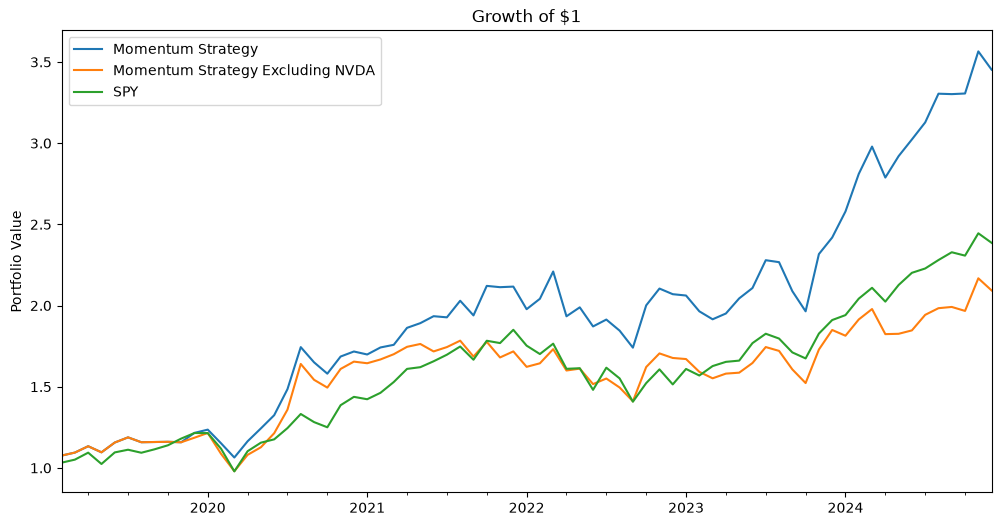

In [105]:
fig, ax = plt.subplots(figsize=(12,6))

portfolio_growth.plot(
    ax=ax,
    label="Momentum Strategy"
)

portfolio_growth_no_nvda.plot(
    ax=ax,
    label="Momentum Strategy Excluding NVDA"
)

spy_growth.plot(
    ax=ax,
    label="SPY"
)

ax.set_title("Growth of $1")
ax.set_ylabel("Portfolio Value")
ax.legend()

plt.show()

In [107]:
no_nvda_metrics = calculate_performance_metrics(
    portfolio_no_nvda,
    portfolio_growth_no_nvda
)

comparison_3 = pd.DataFrame({
    "Momentum Strategy": momentum_metrics,
    "Momentum Ex-NVDA": no_nvda_metrics,
    "SPY": spy_metrics
})

comparison_3

,Momentum Strategy,Momentum Ex-NVDA,SPY
CAGR,0.236374,0.134825,0.160590
Annual Return,0.231468,0.144636,0.162722
Annual Volatility,0.205005,0.200106,0.173038
Sharpe Ratio,1.129083,0.722798,0.940384
Max Drawdown,-0.212237,-0.209353,-0.239272


In [110]:
# Save the performance comparison and holdings history to CSV files
comparison.to_csv("../data/performance_comparison.csv")

holdings_history.to_csv("../data/holdings_history.csv")
